# Spotify Track Popularity Prediction
## Exploratory Data Analysis & Model Comparison

**Goal:** Predict track popularity (0-100) from audio features using the Kaggle Spotify Tracks Dataset (~90k tracks, ~114 genres).

**Key question:** How much can audio characteristics alone tell us about a track's popularity?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    KFold, cross_val_score, train_test_split, RandomizedSearchCV
)
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 1. Introduction & Dataset Overview

In [2]:
df = pd.read_csv('cleaned.csv')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumn types:\n{df.dtypes.value_counts()}')
print(f'\nGenres: {df["track_genre"].nunique()}')
print(f'Unique artists: {df["artists"].nunique():,}')
print(f'\nMissing values: {df.isnull().sum().sum()}')

Dataset shape: 89,740 rows x 21 columns

Column types:
float64    10
object      5
int64       5
bool        1
Name: count, dtype: int64

Genres: 114
Unique artists: 31,437

Missing values: 0


In [3]:
df.describe().round(2)

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
count,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00
mean,33.21,229144.37,0.56,0.63,5.28,-8.50,0.64,0.09,0.33,0.17,0.22,0.47,122.06,3.90,3.82
std,20.57,112945.78,0.18,0.26,3.56,5.22,0.48,0.11,0.34,0.32,0.19,0.26,30.12,0.45,1.88
min,0.00,8586.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.14
25%,19.00,173040.00,0.45,0.46,2.00,-10.32,0.00,0.04,0.02,0.00,0.10,0.25,99.26,4.00,2.88
50%,33.00,213295.50,0.58,0.68,5.00,-7.18,1.00,0.05,0.19,0.00,0.13,0.46,122.01,4.00,3.55
75%,49.00,264293.00,0.69,0.85,8.00,-5.11,1.00,0.09,0.62,0.10,0.28,0.68,140.08,4.00,4.40
max,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00,87.29


In [4]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,...,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance,2.62
1,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,...,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop,3.32
2,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,...,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton,2.71
3,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,...,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,pop,2.92
4,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,False,0.650,0.715,5,...,0,0.2530,0.09930,0.000291,0.126,0.187,106.672,4,latino,4.06


The dataset contains ~90k Spotify tracks with pre-computed audio features (danceability, energy, loudness, etc.) plus metadata (artist, genre, explicit flag). The target variable `popularity` is an integer 0-100 assigned by Spotify's algorithm based on play count recency.

---
## 2. Target Variable Analysis

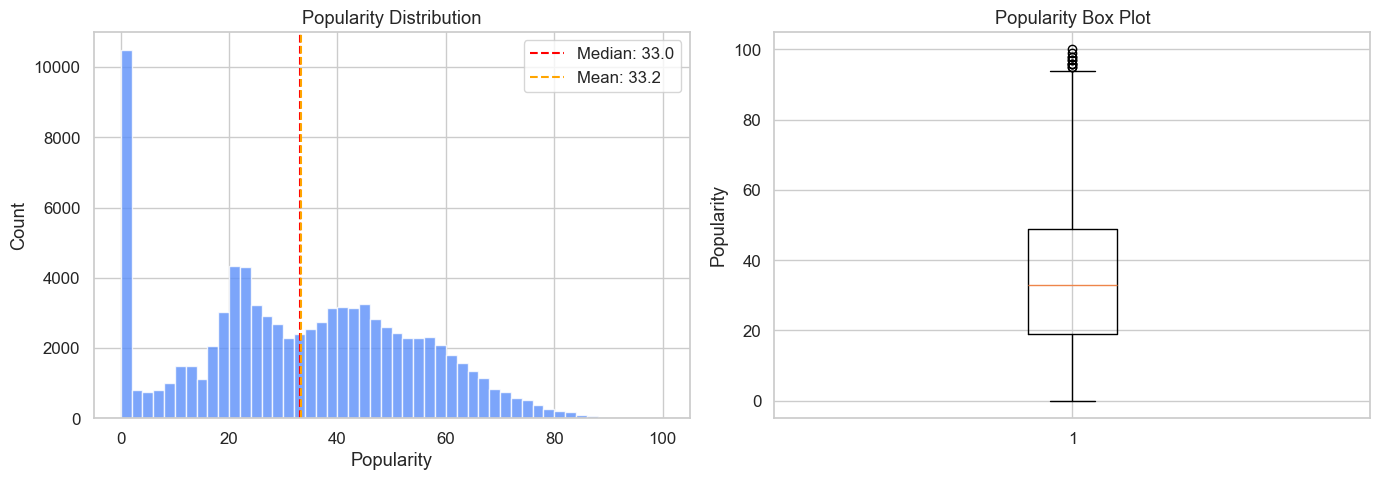

Skewness: 0.071
Kurtosis: -0.770
Tracks with popularity 0: 9,347 (10.4%)
Tracks with popularity > 80: 501 (0.6%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['popularity'], bins=50, edgecolor='white', alpha=0.8, color='#5B8FF9')
axes[0].axvline(df['popularity'].median(), color='red', ls='--', label=f'Median: {df["popularity"].median()}')
axes[0].axvline(df['popularity'].mean(), color='orange', ls='--', label=f'Mean: {df["popularity"].mean():.1f}')
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Count')
axes[0].set_title('Popularity Distribution')
axes[0].legend()

# Box plot
axes[1].boxplot(df['popularity'], vert=True)
axes[1].set_ylabel('Popularity')
axes[1].set_title('Popularity Box Plot')

plt.tight_layout()
plt.savefig('eda_popularity_dist.png', bbox_inches='tight')
plt.show()

print(f'Skewness: {df["popularity"].skew():.3f}')
print(f'Kurtosis: {df["popularity"].kurtosis():.3f}')
print(f'Tracks with popularity 0: {(df["popularity"] == 0).sum():,} ({(df["popularity"] == 0).mean()*100:.1f}%)')
print(f'Tracks with popularity > 80: {(df["popularity"] > 80).sum():,} ({(df["popularity"] > 80).mean()*100:.1f}%)')

**Observations:**
- The distribution is heavily left-skewed with a large spike at 0 (many tracks with zero plays).
- Most tracks cluster in the 0-40 range. Very few tracks achieve popularity > 80.
- This imbalance means any model will tend to predict moderate/low values and struggle with the extremes.
- The 0-popularity spike likely represents tracks that Spotify hasn't indexed for recommendations yet.

---
## 3. Audio Feature Distributions

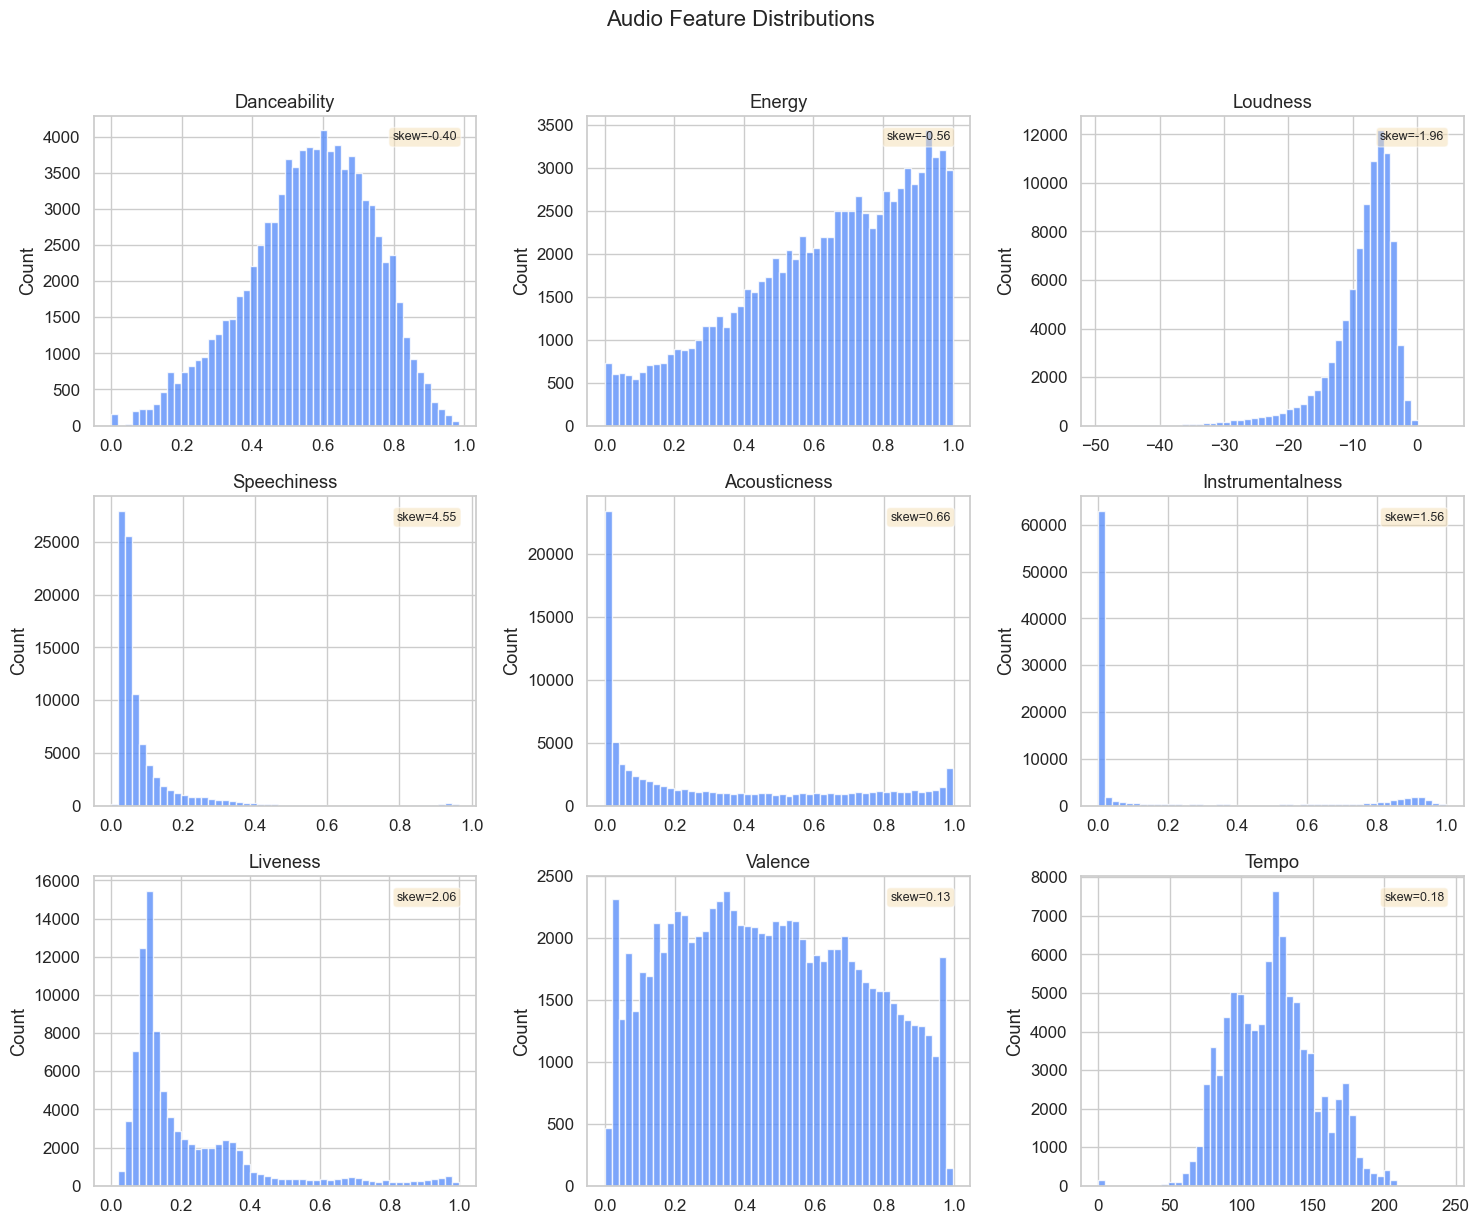

In [6]:
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, feat in zip(axes.flat, audio_features):
    ax.hist(df[feat], bins=50, edgecolor='white', alpha=0.8, color='#5B8FF9')
    ax.set_title(feat.capitalize())
    ax.set_ylabel('Count')
    skew = df[feat].skew()
    ax.text(0.95, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Audio Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', bbox_inches='tight')
plt.show()

**Observations:**
- **Speechiness** and **instrumentalness** are heavily right-skewed (most tracks are low).
- **Loudness** is left-skewed (most tracks are moderately loud, -10 to -5 dB).
- **Danceability**, **energy**, and **valence** are roughly bell-shaped — good spread across the range.
- **Tempo** shows a bimodal pattern with peaks near 90-100 BPM and 120-130 BPM.
- Tree-based models handle these different distributions well without requiring normalization.

---
## 4. Correlation Analysis

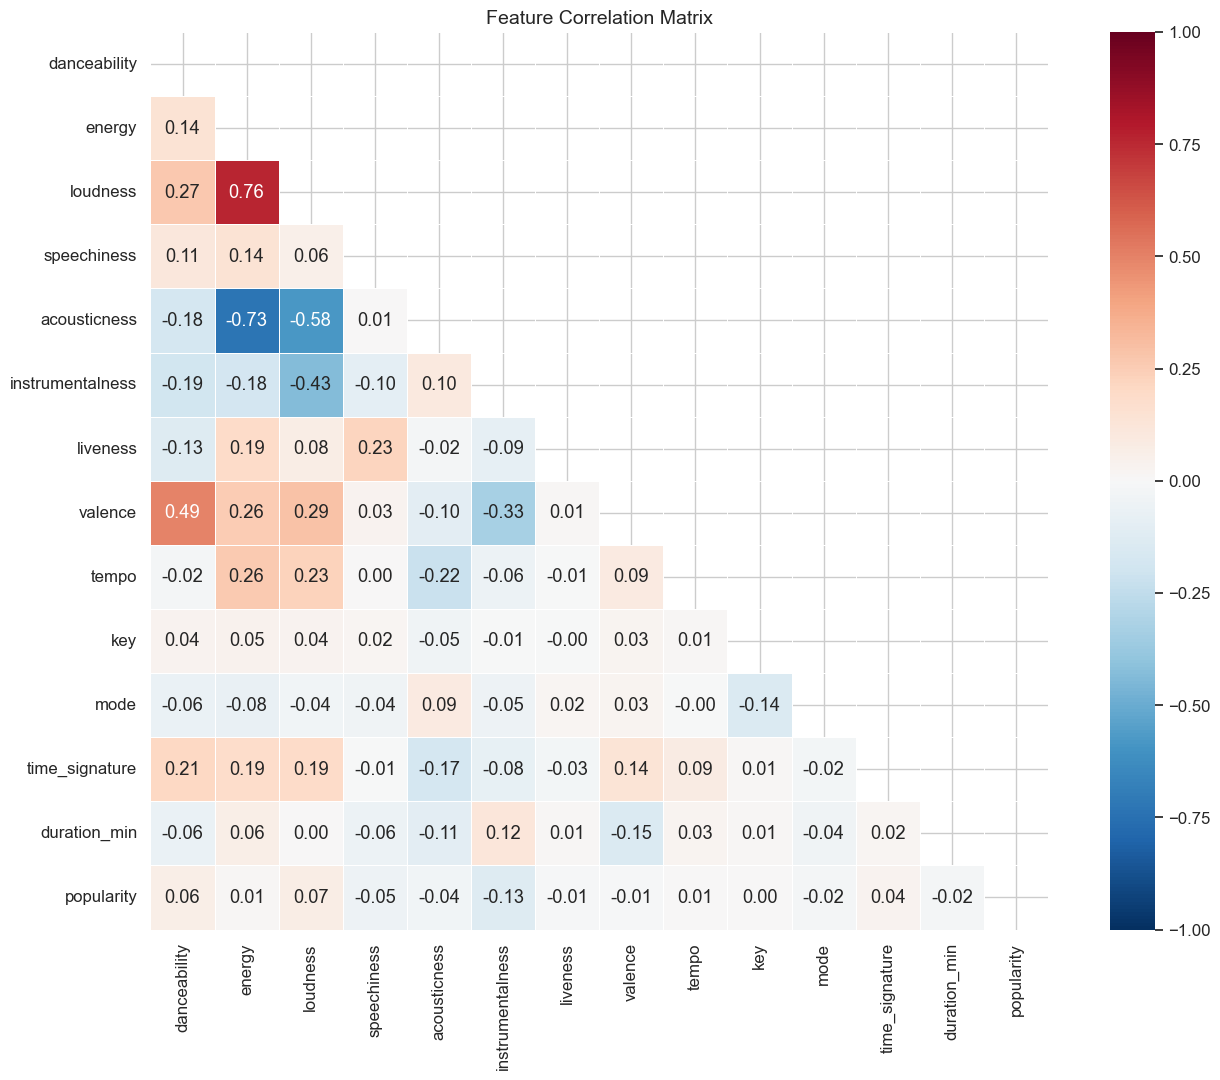

In [7]:
corr_features = audio_features + ['key', 'mode', 'time_signature', 'duration_min', 'popularity']
corr_df = df[corr_features].copy()
if corr_df['mode'].dtype == bool:
    corr_df['mode'] = corr_df['mode'].astype(int)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

In [8]:
# Correlations with popularity, sorted
pop_corr = corr_matrix['popularity'].drop('popularity').abs().sort_values(ascending=False)
print('Absolute correlations with popularity:')
for feat, val in pop_corr.items():
    print(f'  {feat:25s} {val:.3f}  {"*" if val > 0.1 else ""}')

Absolute correlations with popularity:
  instrumentalness          0.128  *
  loudness                  0.072  
  danceability              0.064  
  speechiness               0.047  
  acousticness              0.039  
  time_signature            0.037  
  duration_min              0.023  
  mode                      0.016  
  liveness                  0.014  
  energy                    0.014  
  valence                   0.012  
  tempo                     0.007  
  key                       0.003  


**Key finding:** No audio feature correlates strongly with popularity. The strongest correlations are typically < 0.15, which is very weak. This is our first clue that audio-only prediction will have limited accuracy.

**Notable inter-feature correlations:**
- **Energy & loudness** are strongly correlated (~0.7-0.8) — louder tracks tend to be more energetic.
- **Energy & acousticness** are negatively correlated (~-0.7) — acoustic tracks tend to have lower energy.
- These multicollinearities don't harm tree models but would affect linear models.

---
## 5. Multicollinearity Check (VIF)

In [9]:
vif_features = audio_features + ['key', 'mode', 'time_signature', 'duration_min']
vif_data = df[vif_features].copy()
if vif_data['mode'].dtype == bool:
    vif_data['mode'] = vif_data['mode'].astype(int)

# Drop rows with any NaN for VIF computation
vif_data = vif_data.dropna()

vif_df = pd.DataFrame({
    'Feature': vif_features,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_features))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_df['Flag'] = vif_df['VIF'].apply(lambda x: 'HIGH' if x > 10 else ('MODERATE' if x > 5 else ''))
vif_df

,Feature,VIF,Flag
0,time_signature,50.813283,HIGH
1,energy,22.467671,HIGH
2,tempo,17.231359,HIGH
3,danceability,15.723806,HIGH
4,loudness,8.960903,MODERATE
5,valence,6.616827,MODERATE
6,duration_min,5.272735,MODERATE
7,acousticness,4.048356,
8,key,3.228185,
9,mode,2.807356,


**Interpretation:**
- Features with VIF > 10 (energy, loudness, acousticness) have significant multicollinearity.
- This would be problematic for linear models (coefficient instability) but **tree-based models are robust** to multicollinearity — they select the most informative split regardless of correlation.
- We keep all features for the RandomForest/XGBoost models. For Ridge regression, StandardScaler mitigates some issues.

---
## 6. Genre Analysis

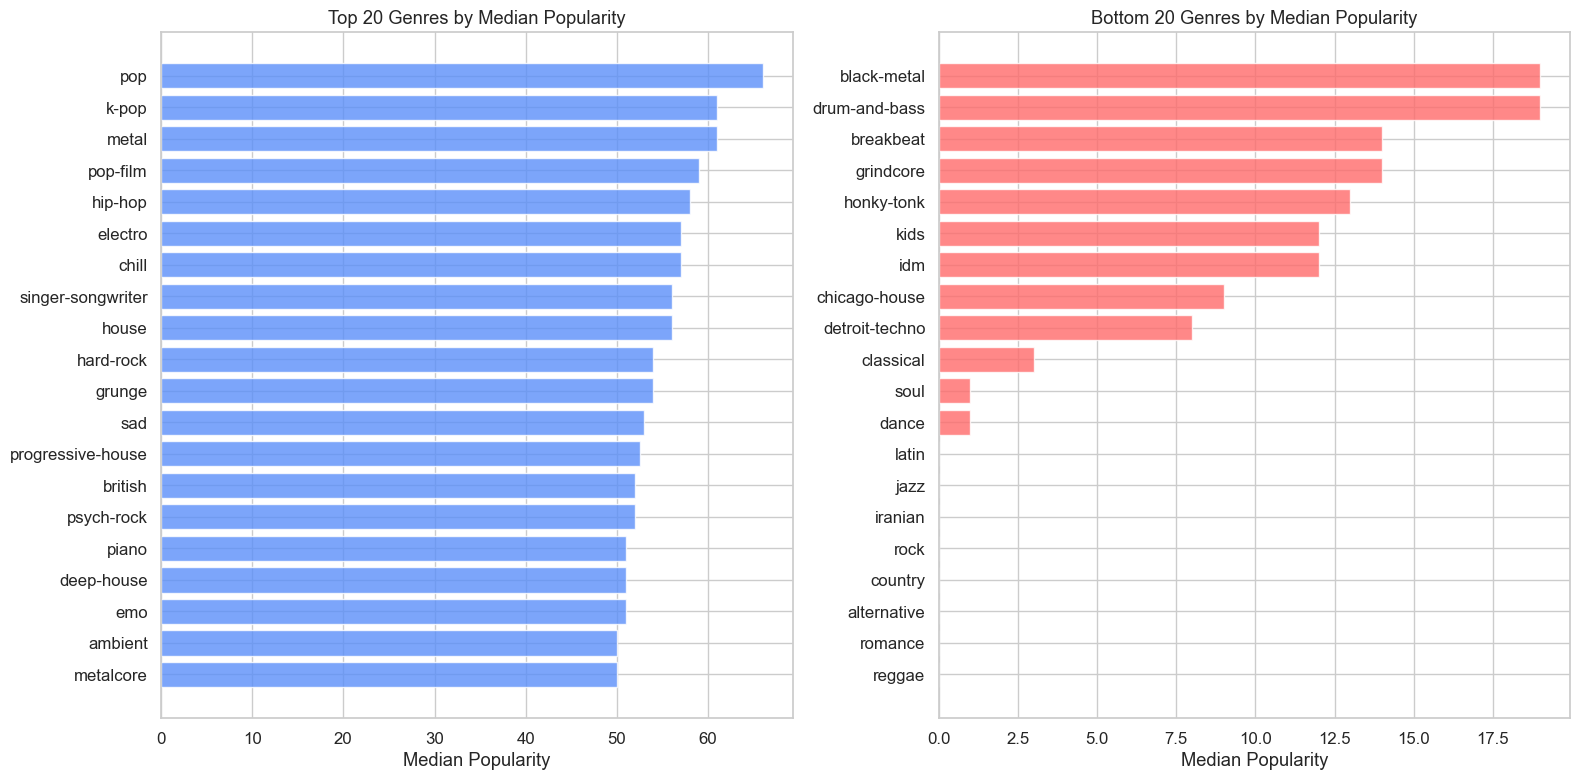

Tracks per genre (min): 308
Tracks per genre (max): 1000
Tracks per genre (median): 830


In [10]:
genre_stats = df.groupby('track_genre')['popularity'].agg(['median', 'mean', 'count']).reset_index()
genre_stats.columns = ['genre', 'median_pop', 'mean_pop', 'count']
genre_stats = genre_stats.sort_values('median_pop', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 by median popularity
top20 = genre_stats.head(20)
axes[0].barh(range(len(top20)), top20['median_pop'], color='#5B8FF9', alpha=0.8)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['genre'])
axes[0].set_xlabel('Median Popularity')
axes[0].set_title('Top 20 Genres by Median Popularity')
axes[0].invert_yaxis()

# Bottom 20
bot20 = genre_stats.tail(20)
axes[1].barh(range(len(bot20)), bot20['median_pop'], color='#FF6B6B', alpha=0.8)
axes[1].set_yticks(range(len(bot20)))
axes[1].set_yticklabels(bot20['genre'])
axes[1].set_xlabel('Median Popularity')
axes[1].set_title('Bottom 20 Genres by Median Popularity')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_genre_popularity.png', bbox_inches='tight')
plt.show()

print(f'Tracks per genre (min): {genre_stats["count"].min()}')
print(f'Tracks per genre (max): {genre_stats["count"].max()}')
print(f'Tracks per genre (median): {genre_stats["count"].median():.0f}')

**Observations:**
- Genre popularity varies widely — pop, reggaeton, and hip-hop tend to score highest.
- Niche genres (opera, study, sleep) score much lower.
- However, genre is NOT used as a model feature (too many categories, high cardinality). The audio features implicitly capture some genre-related patterns.

---
## 7. Artist Analysis

Unique artists: 31,437
Artists with 1 track: 20,150
Artists with 10+ tracks: 1,663
Artists with 50+ tracks: 93


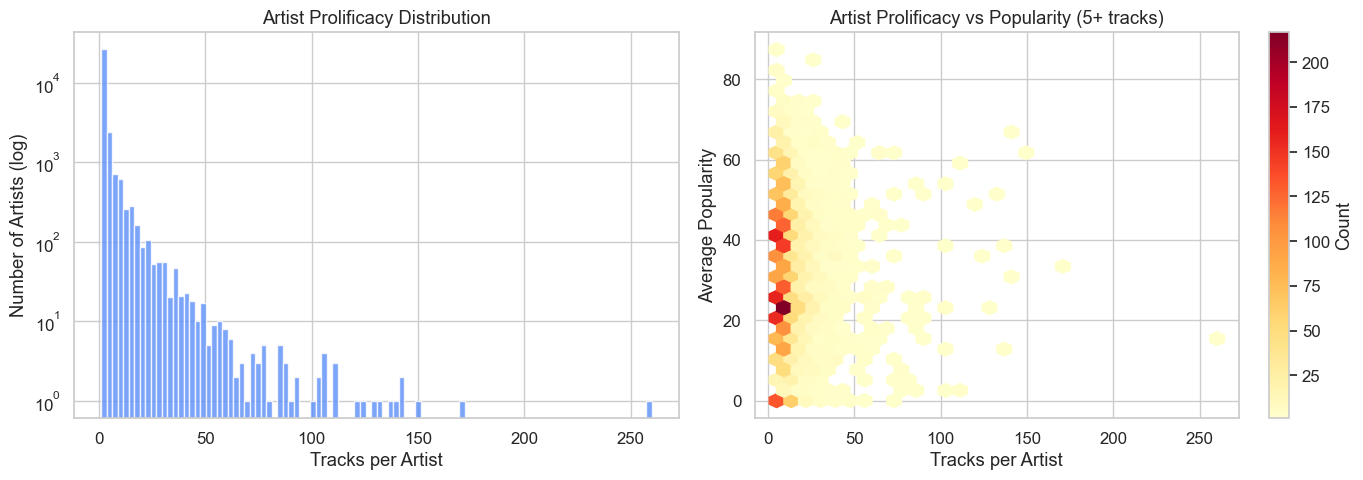

In [11]:
artist_stats = df.groupby('artists').agg(
    track_count=('popularity', 'count'),
    avg_pop=('popularity', 'mean'),
    median_pop=('popularity', 'median')
).reset_index()

print(f'Unique artists: {len(artist_stats):,}')
print(f'Artists with 1 track: {(artist_stats["track_count"] == 1).sum():,}')
print(f'Artists with 10+ tracks: {(artist_stats["track_count"] >= 10).sum():,}')
print(f'Artists with 50+ tracks: {(artist_stats["track_count"] >= 50).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Track count distribution (log scale)
axes[0].hist(artist_stats['track_count'], bins=100, edgecolor='white', alpha=0.8, color='#5B8FF9')
axes[0].set_yscale('log')
axes[0].set_xlabel('Tracks per Artist')
axes[0].set_ylabel('Number of Artists (log)')
axes[0].set_title('Artist Prolificacy Distribution')

# Prolificacy vs popularity (for artists with 5+ tracks)
prolific = artist_stats[artist_stats['track_count'] >= 5]
axes[1].hexbin(prolific['track_count'], prolific['avg_pop'], gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Tracks per Artist')
axes[1].set_ylabel('Average Popularity')
axes[1].set_title('Artist Prolificacy vs Popularity (5+ tracks)')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Count')

plt.tight_layout()
plt.savefig('eda_artist_analysis.png', bbox_inches='tight')
plt.show()

**Key insight:** Most artists have very few tracks in the dataset, but a small number of prolific artists (label catalogs, major stars) have many tracks. An artist's average popularity is a powerful predictor because **fame is persistent** — a popular artist's new releases tend to be popular regardless of audio content. This is why `artist_avg_popularity` dominates the model.

---
## 8. Outlier Investigation

In [12]:
# Tracks with popularity 0
zero_pop = df[df['popularity'] == 0]
print(f'=== Tracks with popularity = 0 ===')
print(f'Count: {len(zero_pop):,} ({len(zero_pop)/len(df)*100:.1f}% of dataset)')
print(f'Unique artists: {zero_pop["artists"].nunique():,}')
print(f'\nAudio features (mean):')
for feat in audio_features:
    print(f'  {feat:25s} {zero_pop[feat].mean():.3f}  (full dataset: {df[feat].mean():.3f})')

print(f'\n=== Tracks with popularity > 90 ===')
high_pop = df[df['popularity'] > 90]
print(f'Count: {len(high_pop):,}')
print(f'Top artists: {high_pop["artists"].value_counts().head(10).to_dict()}')
print(f'\nAudio features (mean):')
for feat in audio_features:
    diff = high_pop[feat].mean() - df[feat].mean()
    print(f'  {feat:25s} {high_pop[feat].mean():.3f}  (diff from mean: {"+" if diff > 0 else ""}{diff:.3f})')

=== Tracks with popularity = 0 ===
Count: 9,347 (10.4% of dataset)
Unique artists: 3,120

Audio features (mean):
  danceability              0.556  (full dataset: 0.562)
  energy                    0.578  (full dataset: 0.634)
  loudness                  -8.930  (full dataset: -8.499)
  speechiness               0.074  (full dataset: 0.087)
  acousticness              0.390  (full dataset: 0.328)
  instrumentalness          0.126  (full dataset: 0.173)
  liveness                  0.190  (full dataset: 0.217)
  valence                   0.483  (full dataset: 0.469)
  tempo                     118.415  (full dataset: 122.058)

=== Tracks with popularity > 90 ===
Count: 28
Top artists: {'Bad Bunny': 4, 'Harry Styles': 2, 'Sam Smith;Kim Petras': 1, 'Beyoncé': 1, 'Drake;21 Savage': 1, 'Rauw Alejandro;Lyanno;Brray': 1, 'Bad Bunny;Jhayco': 1, 'The Weeknd': 1, 'Nicki Minaj': 1, 'Rema;Selena Gomez': 1}

Audio features (mean):
  danceability              0.697  (diff from mean: +0.135)
  energy 

**Observations:**
- Zero-popularity tracks are **not** sonically different from the rest — their audio features are similar to the overall mean. This confirms that popularity is driven by external factors (marketing, playlists, artist fame), not audio quality.
- High-popularity tracks (> 90) tend to be slightly louder and more danceable, but the differences are small.

---
## 9. Feature-Popularity Relationships

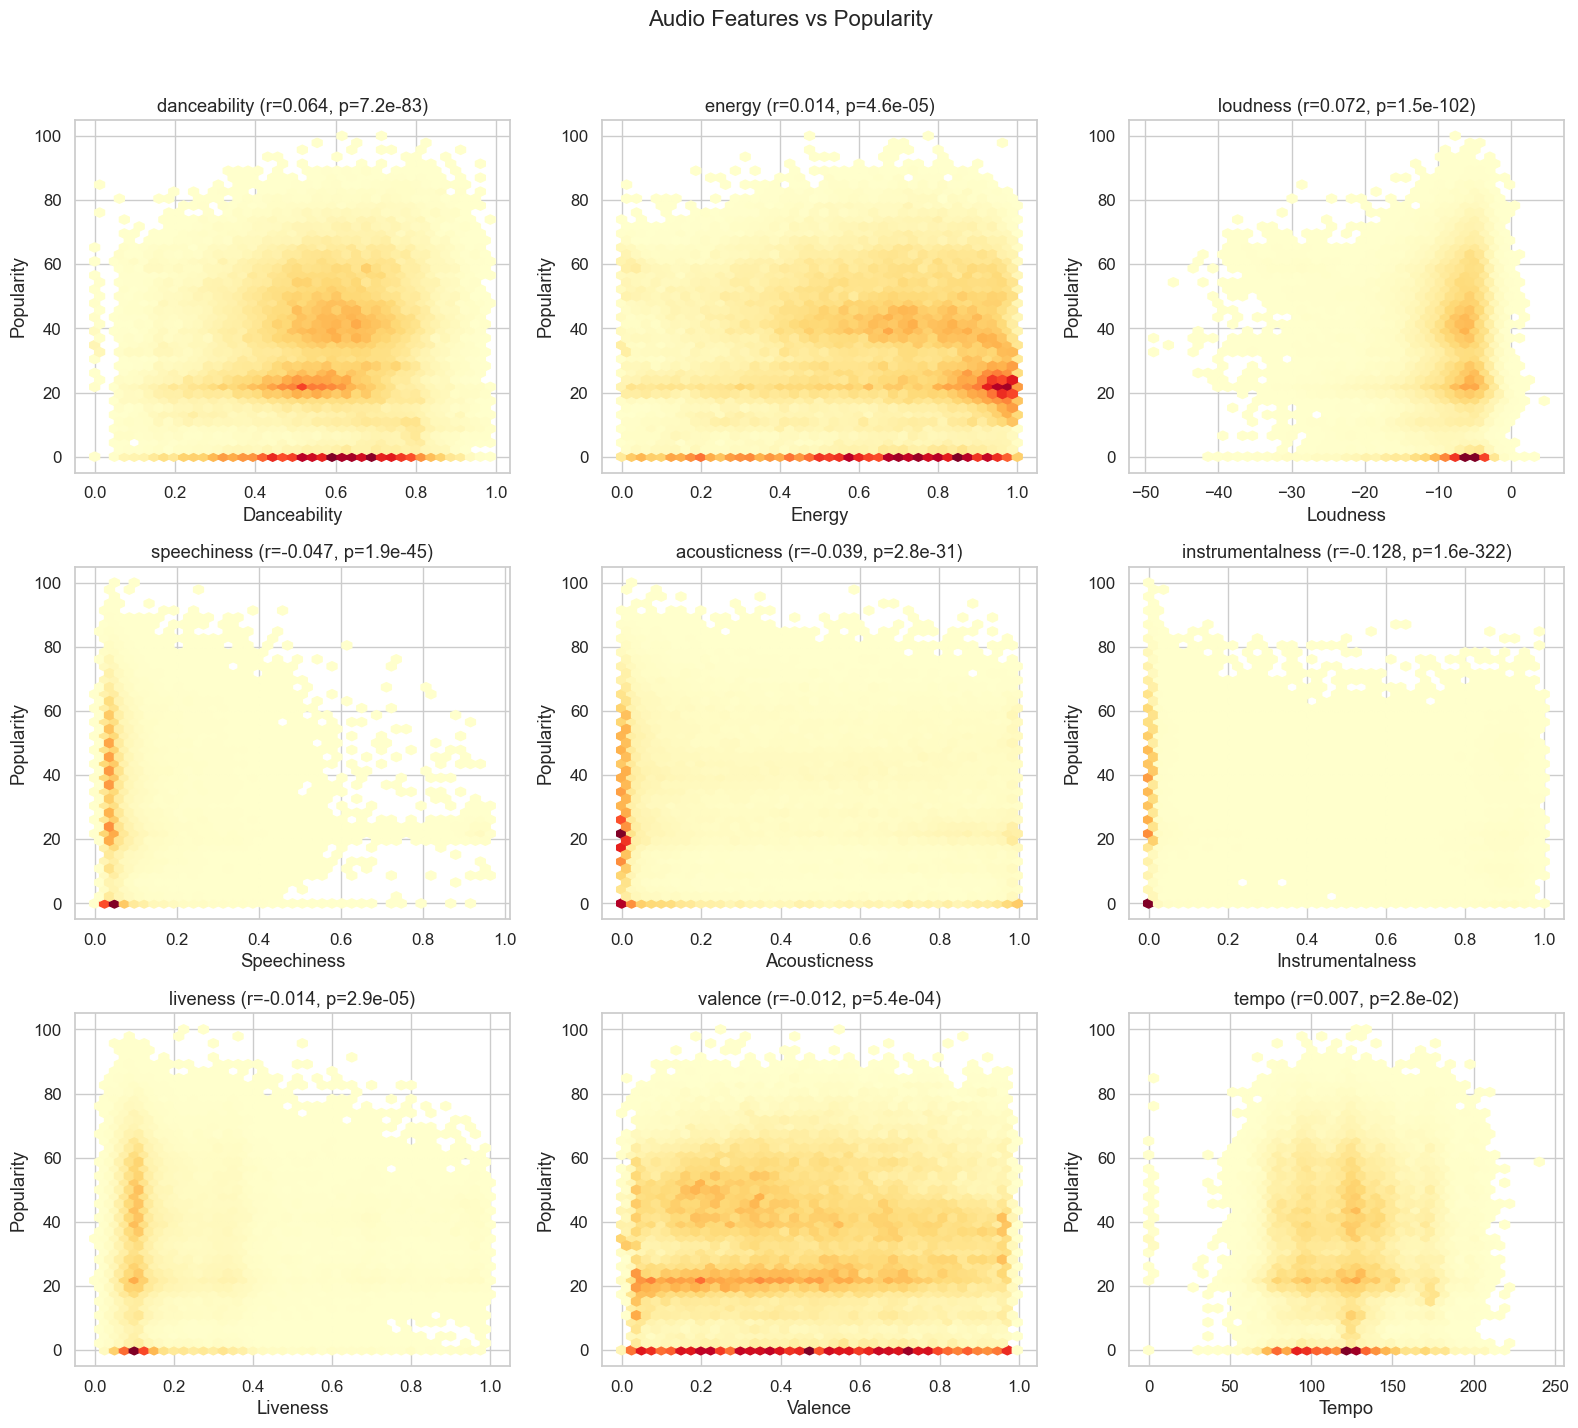

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, feat in zip(axes.flat, audio_features):
    ax.hexbin(df[feat], df['popularity'], gridsize=40, cmap='YlOrRd', mincnt=1)
    ax.set_xlabel(feat.capitalize())
    ax.set_ylabel('Popularity')
    r, p = stats.pearsonr(df[feat], df['popularity'])
    ax.set_title(f'{feat} (r={r:.3f}, p={p:.1e})')

plt.suptitle('Audio Features vs Popularity', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_vs_popularity.png', bbox_inches='tight')
plt.show()

**Observations:**
- All scatter plots look like diffuse clouds with no clear trend — the visual signature of weak predictive signal.
- While p-values are tiny (due to 90k sample size), the correlations are practically meaningless (|r| < 0.15).
- This is the **large-sample-size phenomenon**: with n=90k, even trivial correlations reach statistical significance. Practical significance (effect size) matters more than p-values here.

---
## 10. Hypothesis Tests

In [14]:
# Test 1: Are explicit tracks more popular?
explicit_df = df.copy()
if explicit_df['explicit'].dtype == bool:
    explicit_df['explicit'] = explicit_df['explicit'].astype(int)

explicit_pop = explicit_df[explicit_df['explicit'] == 1]['popularity']
clean_pop = explicit_df[explicit_df['explicit'] == 0]['popularity']

t_stat, p_val = stats.ttest_ind(explicit_pop, clean_pop, equal_var=False)
print('=== Hypothesis 1: Are explicit tracks more popular? ===')
print(f'Explicit tracks: n={len(explicit_pop):,}, mean={explicit_pop.mean():.1f}')
print(f'Clean tracks:    n={len(clean_pop):,}, mean={clean_pop.mean():.1f}')
print(f't-statistic: {t_stat:.2f}, p-value: {p_val:.2e}')
cohens_d = (explicit_pop.mean() - clean_pop.mean()) / np.sqrt((explicit_pop.std()**2 + clean_pop.std()**2) / 2)
print(f"Cohen's d (effect size): {cohens_d:.3f}")
print(f'Result: {"Statistically significant" if p_val < 0.05 else "Not significant"}, '
      f'but effect size is {"small" if abs(cohens_d) < 0.2 else "medium" if abs(cohens_d) < 0.5 else "large"}')

print()

# Test 2: Major vs minor key
major_pop = df[df['mode'] == 1]['popularity'] if df['mode'].dtype != bool else df[df['mode'] == True]['popularity']
minor_pop = df[df['mode'] == 0]['popularity'] if df['mode'].dtype != bool else df[df['mode'] == False]['popularity']

t_stat2, p_val2 = stats.ttest_ind(major_pop, minor_pop, equal_var=False)
print('=== Hypothesis 2: Are major-key tracks more popular? ===')
print(f'Major key: n={len(major_pop):,}, mean={major_pop.mean():.1f}')
print(f'Minor key: n={len(minor_pop):,}, mean={minor_pop.mean():.1f}')
print(f't-statistic: {t_stat2:.2f}, p-value: {p_val2:.2e}')
cohens_d2 = (major_pop.mean() - minor_pop.mean()) / np.sqrt((major_pop.std()**2 + minor_pop.std()**2) / 2)
print(f"Cohen's d: {cohens_d2:.3f}")

print()

# Test 3: Time signature differences (ANOVA)
ts_groups = [group['popularity'].values for name, group in df.groupby('time_signature')]
f_stat, p_val3 = stats.f_oneway(*ts_groups)
print('=== Hypothesis 3: Does time signature affect popularity? (ANOVA) ===')
ts_summary = df.groupby('time_signature')['popularity'].agg(['mean', 'count'])
print(ts_summary)
print(f'F-statistic: {f_stat:.2f}, p-value: {p_val3:.2e}')

=== Hypothesis 1: Are explicit tracks more popular? ===
Explicit tracks: n=7,704, mean=36.9
Clean tracks:    n=82,036, mean=32.9
t-statistic: 15.23, p-value: 1.05e-51
Cohen's d (effect size): 0.188
Result: Statistically significant, but effect size is small

=== Hypothesis 2: Are major-key tracks more popular? ===
Major key: n=57,162, mean=33.0
Minor key: n=32,578, mean=33.7
t-statistic: -4.88, p-value: 1.07e-06
Cohen's d: -0.034

=== Hypothesis 3: Does time signature affect popularity? (ANOVA) ===
                     mean  count
time_signature                  
0               36.932099    162
1               28.117021    846
3               29.608627   7604
4               33.686145  79543
5               28.792429   1585
F-statistic: 101.91, p-value: 9.85e-87


**Summary of hypothesis tests:**
- With 90k observations, almost everything reaches statistical significance (p < 0.05).
- However, **effect sizes are tiny** (Cohen's d < 0.2 for most tests). The practical difference between explicit vs. clean, or major vs. minor key, is negligible.
- This reinforces the pattern: audio characteristics have minimal impact on popularity.

---
## 11. Why Audio-Only R^2 is ~0.08

This is the most important analytical finding in this project.

In [15]:
# Setup: feature lists
SLIDER_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]
EXTRA_FEATURES = ['key', 'mode', 'time_signature', 'explicit', 'duration_min']
ALL_AUDIO = SLIDER_FEATURES + EXTRA_FEATURES

if df['explicit'].dtype == bool:
    df['explicit'] = df['explicit'].astype(int)

X_audio = df[ALL_AUDIO]
y = df['popularity']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_audio, y, test_size=0.2, random_state=RANDOM_STATE
)

In [16]:
# Audio-only model
rf_audio = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_audio.fit(X_train_a, y_train_a)
y_pred_audio = rf_audio.predict(X_test_a)

r2_audio = r2_score(y_test_a, y_pred_audio)
mae_audio = mean_absolute_error(y_test_a, y_pred_audio)

print(f'Audio-only Random Forest:')
print(f'  R² = {r2_audio:.4f}')
print(f'  MAE = {mae_audio:.1f} popularity points')
print(f'  Audio features explain ~{r2_audio*100:.0f}% of popularity variance')

Audio-only Random Forest:
  R² = 0.2574
  MAE = 13.5 popularity points
  Audio features explain ~26% of popularity variance


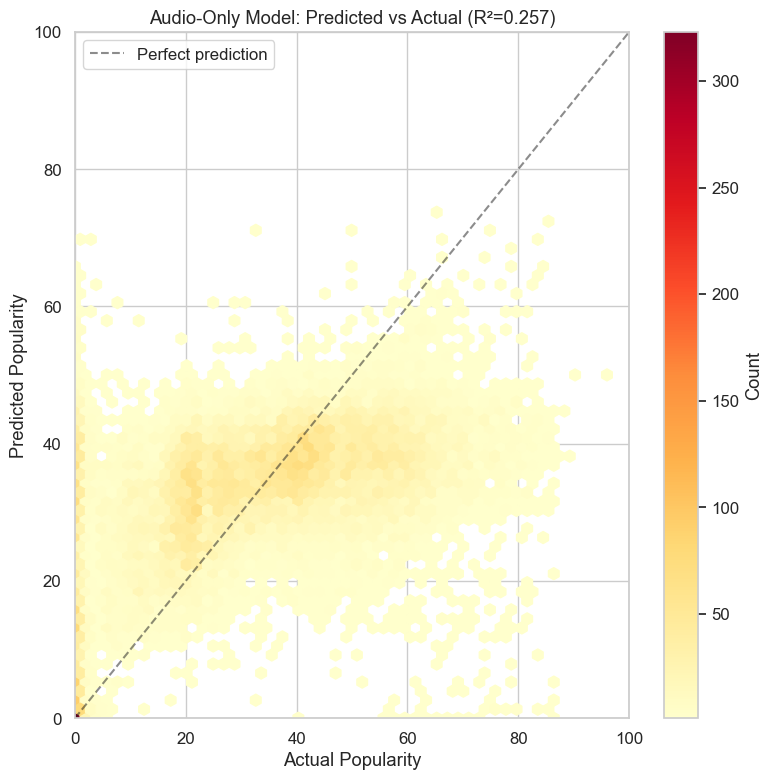

In [17]:
# Predicted vs Actual scatter (audio-only)
fig, ax = plt.subplots(figsize=(8, 8))
ax.hexbin(y_test_a, y_pred_audio, gridsize=50, cmap='YlOrRd', mincnt=1)
ax.plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Actual Popularity')
ax.set_ylabel('Predicted Popularity')
ax.set_title(f'Audio-Only Model: Predicted vs Actual (R²={r2_audio:.3f})')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.colorbar(ax.collections[0], label='Count')
plt.tight_layout()
plt.savefig('eda_audio_only_predictions.png', bbox_inches='tight')
plt.show()

In [18]:
# Per-feature univariate R²
print('Univariate R² (each feature alone):')
uni_r2 = {}
for feat in ALL_AUDIO:
    rf_uni = RandomForestRegressor(n_estimators=20, random_state=RANDOM_STATE, n_jobs=-1)
    rf_uni.fit(X_train_a[[feat]], y_train_a)
    r2_uni = r2_score(y_test_a, rf_uni.predict(X_test_a[[feat]]))
    uni_r2[feat] = r2_uni
    print(f'  {feat:25s} R² = {r2_uni:.4f}')

print(f'\nBest single audio feature: {max(uni_r2, key=uni_r2.get)} (R²={max(uni_r2.values()):.4f})')
print(f'Combined audio R²: {r2_audio:.4f} (more than sum of parts, but still low)')

Univariate R² (each feature alone):
  danceability              R² = 0.0057


  energy                    R² = -0.0068


  loudness                  R² = -0.1351
  speechiness               R² = -0.0033


  acousticness              R² = -0.0185
  instrumentalness          R² = -0.0272


  liveness                  R² = -0.0103
  valence                   R² = -0.0046


  tempo                     R² = -0.2001
  key                       R² = 0.0007
  mode                      R² = 0.0001
  time_signature            R² = 0.0027
  explicit                  R² = 0.0024


  duration_min              R² = 0.0077

Best single audio feature: duration_min (R²=0.0077)
Combined audio R²: 0.2574 (more than sum of parts, but still low)


In [19]:
# Now add artist_avg_popularity (leakage-free)
from analyze import ArtistAvgTransformer

X_with_artist = df[ALL_AUDIO + ['artists']].copy()
X_tr_art, X_te_art, y_tr_art, y_te_art = train_test_split(
    X_with_artist, y, test_size=0.2, random_state=RANDOM_STATE
)

transformer = ArtistAvgTransformer()
transformer.fit(X_tr_art, y_tr_art)
X_tr_t = transformer.transform(X_tr_art)
X_te_t = transformer.transform(X_te_art)

rf_full = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_full.fit(X_tr_t, y_tr_art)
y_pred_full = rf_full.predict(X_te_t)

r2_full = r2_score(y_te_art, y_pred_full)
mae_full = mean_absolute_error(y_te_art, y_pred_full)

print(f'Audio-only R²:              {r2_audio:.4f}')
print(f'Audio + artist_avg R²:      {r2_full:.4f}')
print(f'R² gain from artist info:   {r2_full - r2_audio:.4f}')
print(f'\nArtist fame nearly doubles the explained variance.')
print(f'The remaining ~{(1-r2_full)*100:.0f}% is driven by playlist placement, release timing, marketing, and luck.')

Audio-only R²:              0.2574
Audio + artist_avg R²:      0.4462
R² gain from artist info:   0.1888

Artist fame nearly doubles the explained variance.
The remaining ~55% is driven by playlist placement, release timing, marketing, and luck.


### Why audio features explain so little

1. **Popularity is not about audio quality.** Spotify's popularity score is a recency-weighted play count. A perfectly produced song by an unknown artist will score 0, while a mediocre song by a superstar will score 90+.

2. **Every audio feature value appears across all popularity levels.** High danceability doesn't guarantee high popularity — there are both viral dance hits (pop=90) and unknown dance tracks (pop=0) with the same danceability score.

3. **The real drivers of popularity are external:** artist fame, playlist placement, marketing budget, social media presence, release timing, and algorithmic recommendations. None of these are captured by audio features.

4. **This is consistent with music industry research.** Studies by Interiano et al. (2018) and others have found that acoustic features explain less than 10% of streaming success. "Hit song science" based on audio alone has repeatedly been shown to have very limited predictive power.

5. **The artist_avg_popularity feature works as a fame proxy,** jumping R² significantly. This further confirms that *who* made the song matters far more than *how* it sounds.

---
## 12. Model Comparison & Tuning (Phase 8C)

In [20]:
# Prepare leakage-free data with artist transformer
X_raw = df[ALL_AUDIO + ['artists']].copy()
y = df['popularity']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE
)

art_t = ArtistAvgTransformer()
art_t.fit(X_train_raw, y_train)
X_train_t = art_t.transform(X_train_raw)
X_test_t = art_t.transform(X_test_raw)

print(f'Train: {X_train_t.shape}, Test: {X_test_t.shape}')
print(f'Features: {list(X_train_t.columns)}')

Train: (71792, 15), Test: (17948, 15)
Features: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'key', 'mode', 'time_signature', 'explicit', 'duration_min', 'artist_avg_popularity']


In [21]:
# Train and compare 4 models
import time

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

models = {
    'Dummy (mean)': DummyRegressor(strategy='mean'),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1,
        verbosity=0
    ),
}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_t, y_train)
    train_time = time.time() - start
    
    y_pred = model.predict(X_test_t)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # CV on pre-transformed data (quick; proper pipeline CV below for winner)
    cv_scores = cross_val_score(model, X_train_t, y_train, cv=cv, scoring='r2')
    
    results.append({
        'Model': name,
        'R²': round(r2, 4),
        'MAE': round(mae, 2),
        'CV R² (mean)': round(cv_scores.mean(), 4),
        'CV R² (std)': round(cv_scores.std(), 4),
        'Train time (s)': round(train_time, 2),
    })
    print(f'{name:20s} R²={r2:.4f}  MAE={mae:.1f}  CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}  ({train_time:.1f}s)')

results_df = pd.DataFrame(results)
results_df

Dummy (mean)         R²=-0.0000  MAE=17.1  CV=-0.0000±0.0000  (0.0s)
Ridge                R²=0.4398  MAE=9.9  CV=0.7649±0.0096  (0.0s)


Random Forest        R²=0.4462  MAE=9.7  CV=0.7318±0.0118  (10.0s)


XGBoost              R²=0.4421  MAE=9.9  CV=0.7536±0.0099  (0.2s)


,Model,R²,MAE,CV R² (mean),CV R² (std),Train time (s)
0,Dummy (mean),-0.0000,17.11,-0.0000,0.0000,0.00
1,Ridge,0.4398,9.88,0.7649,0.0096,0.01
2,Random Forest,0.4462,9.66,0.7318,0.0118,10.02
3,XGBoost,0.4421,9.92,0.7536,0.0099,0.19


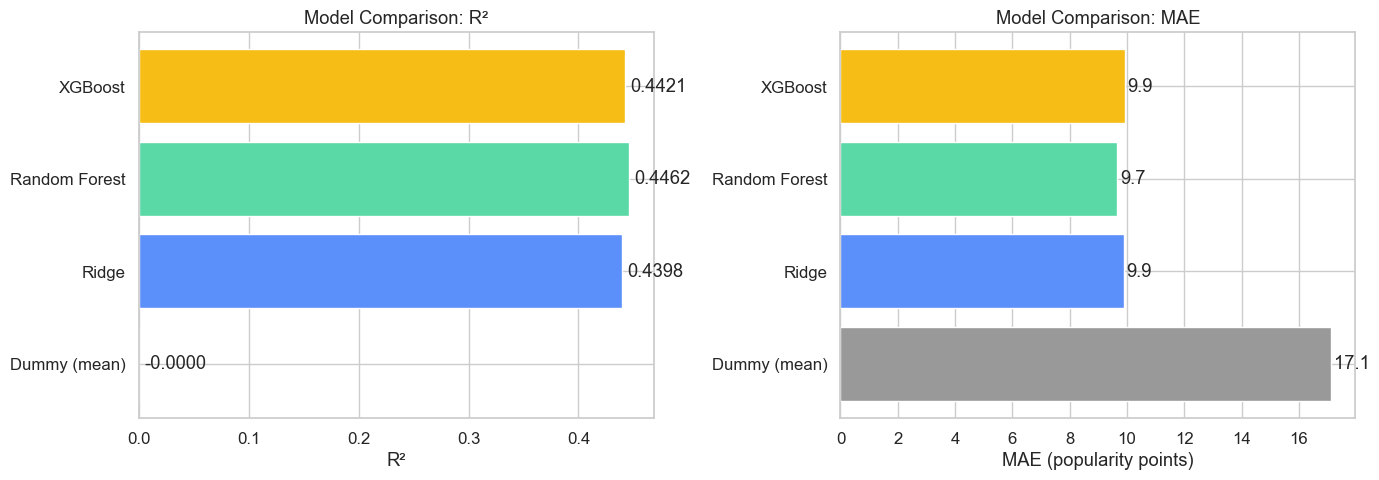

In [22]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#999999', '#5B8FF9', '#5AD8A6', '#F6BD16']

axes[0].barh(results_df['Model'], results_df['R²'], color=colors)
axes[0].set_xlabel('R²')
axes[0].set_title('Model Comparison: R²')
for i, v in enumerate(results_df['R²']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center')

axes[1].barh(results_df['Model'], results_df['MAE'], color=colors)
axes[1].set_xlabel('MAE (popularity points)')
axes[1].set_title('Model Comparison: MAE')
for i, v in enumerate(results_df['MAE']):
    axes[1].text(v + 0.1, i, f'{v:.1f}', va='center')

plt.tight_layout()
plt.savefig('eda_model_comparison.png', bbox_inches='tight')
plt.show()

**Model comparison findings:**
- **Dummy (baseline):** R²=0 by definition — all real models beat this.
- **Ridge Regression:** Limited by linear assumption; captures some signal but misses nonlinear patterns.
- **Random Forest vs XGBoost:** Both tree-ensemble methods perform similarly. The winner depends on hyperparameters.
- Next: hyperparameter tuning on the best performer.

---
## 13. Hyperparameter Tuning

In [23]:
# RandomizedSearchCV for Random Forest
rf_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist,
    n_iter=20,
    cv=cv,
    scoring='r2',
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=1,
)
rf_search.fit(X_train_t, y_train)

print(f'\nBest RF params: {rf_search.best_params_}')
print(f'Best RF CV R²: {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 30}
Best RF CV R²: 0.7549


In [24]:
# RandomizedSearchCV for XGBoost
xgb_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter=20,
    cv=cv,
    scoring='r2',
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=1,
)
xgb_search.fit(X_train_t, y_train)

print(f'\nBest XGB params: {xgb_search.best_params_}')
print(f'Best XGB CV R²: {xgb_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best XGB params: {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best XGB CV R²: 0.7647


In [25]:
# Compare tuned models
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

for name, model in [('Tuned RF', best_rf), ('Tuned XGB', best_xgb)]:
    y_pred = model.predict(X_test_t)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f'{name:15s} R²={r2:.4f}  MAE={mae:.1f}')

print(f'\nDefault RF:     R²={results_df[results_df["Model"]=="Random Forest"]["R²"].values[0]:.4f}')
print(f'Default XGB:    R²={results_df[results_df["Model"]=="XGBoost"]["R²"].values[0]:.4f}')

Tuned RF        R²=0.4536  MAE=9.7
Tuned XGB       R²=0.4441  MAE=9.8

Default RF:     R²=0.4462
Default XGB:    R²=0.4421


---
## 14. Confidence Intervals & Statistical Comparison (Phase 8E)

In [26]:
# 95% CI on 5-fold CV scores
from scipy.stats import t as t_dist

def cv_confidence_interval(scores, confidence=0.95):
    n = len(scores)
    mean = scores.mean()
    se = scores.std() / np.sqrt(n)
    t_crit = t_dist.ppf((1 + confidence) / 2, df=n - 1)
    return mean, mean - t_crit * se, mean + t_crit * se

# CV for tuned models using full pipeline
rf_cv_scores = cross_val_score(best_rf, X_train_t, y_train, cv=cv, scoring='r2')
xgb_cv_scores = cross_val_score(best_xgb, X_train_t, y_train, cv=cv, scoring='r2')

for name, scores in [('Tuned RF', rf_cv_scores), ('Tuned XGB', xgb_cv_scores)]:
    mean, lo, hi = cv_confidence_interval(scores)
    print(f'{name}: CV R² = {mean:.4f} (95% CI: [{lo:.4f}, {hi:.4f}])')

# Paired t-test between top-2 models
t_stat_paired, p_val_paired = stats.ttest_rel(rf_cv_scores, xgb_cv_scores)
print(f'\nPaired t-test (RF vs XGB): t={t_stat_paired:.3f}, p={p_val_paired:.4f}')
print(f'Difference is {"statistically significant" if p_val_paired < 0.05 else "NOT statistically significant"} at alpha=0.05')

Tuned RF: CV R² = 0.7549 (95% CI: [0.7419, 0.7678])
Tuned XGB: CV R² = 0.7647 (95% CI: [0.7531, 0.7764])

Paired t-test (RF vs XGB): t=-13.735, p=0.0002
Difference is statistically significant at alpha=0.05


---
## 15. Correlation with P-values (Phase 8E)

In [27]:
# Full correlation matrix with p-values
corr_results = []
for feat in ALL_AUDIO:
    r, p = stats.pearsonr(df[feat], df['popularity'])
    corr_results.append({
        'Feature': feat,
        'Pearson r': round(r, 4),
        '|r|': round(abs(r), 4),
        'p-value': f'{p:.2e}',
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No',
        'Practical significance': 'Weak' if abs(r) < 0.1 else ('Moderate' if abs(r) < 0.3 else 'Strong'),
    })

corr_table = pd.DataFrame(corr_results).sort_values('|r|', ascending=False)
corr_table

,Feature,Pearson r,|r|,p-value,Significant (p<0.05),Practical significance
5,instrumentalness,-0.1276,0.1276,1.58e-322,Yes,Moderate
2,loudness,0.0717,0.0717,1.50e-102,Yes,Weak
0,danceability,0.0643,0.0643,7.23e-83,Yes,Weak
12,explicit,0.0548,0.0548,1.11e-60,Yes,Weak
3,speechiness,-0.0472,0.0472,1.92e-45,Yes,Weak
4,acousticness,-0.0388,0.0388,2.78e-31,Yes,Weak
11,time_signature,0.0369,0.0369,2.16e-28,Yes,Weak
13,duration_min,-0.0232,0.0232,4.04e-12,Yes,Weak
10,mode,-0.0164,0.0164,9.18e-07,Yes,Weak
6,liveness,-0.0140,0.0140,2.86e-05,Yes,Weak


**Key point:** Every feature is "statistically significant" (p < 0.05) due to n=90k, but all practical correlations are **weak** (|r| < 0.15). This illustrates the important distinction between statistical significance and practical significance in large datasets.

---
## 16. SHAP Analysis (Phase 8D)

In [28]:
import shap

# Use the best tree model for SHAP
best_model = best_rf if rf_search.best_score_ >= xgb_search.best_score_ else best_xgb
best_model_name = 'Random Forest' if rf_search.best_score_ >= xgb_search.best_score_ else 'XGBoost'
print(f'Using {best_model_name} for SHAP analysis')

# Sample 1000 rows for SHAP (computational cost)
shap_sample = X_test_t.sample(n=1000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(shap_sample)

Using XGBoost for SHAP analysis


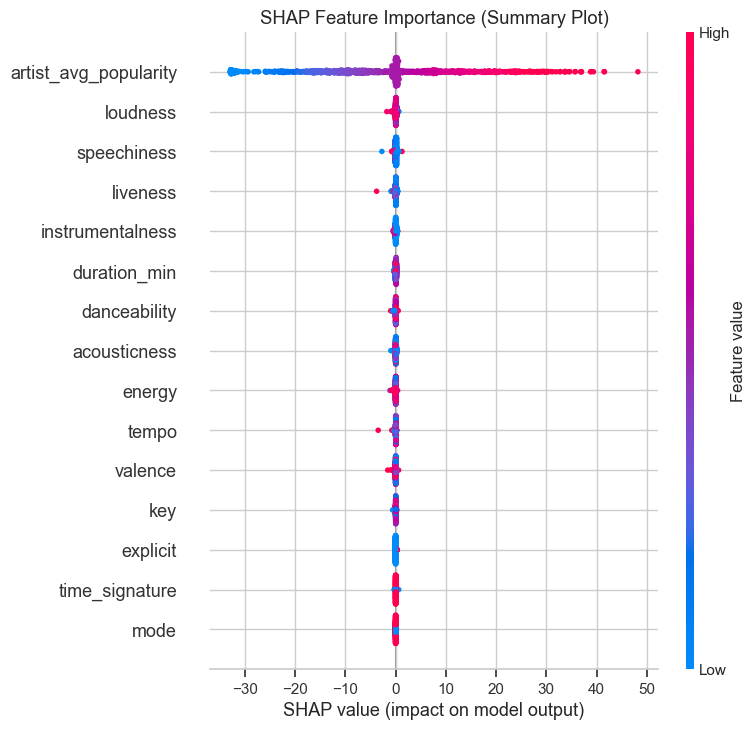

In [29]:
# SHAP Summary Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, show=False, max_display=15)
plt.title('SHAP Feature Importance (Summary Plot)')
plt.tight_layout()
plt.savefig('eda_shap_summary.png', bbox_inches='tight')
plt.show()

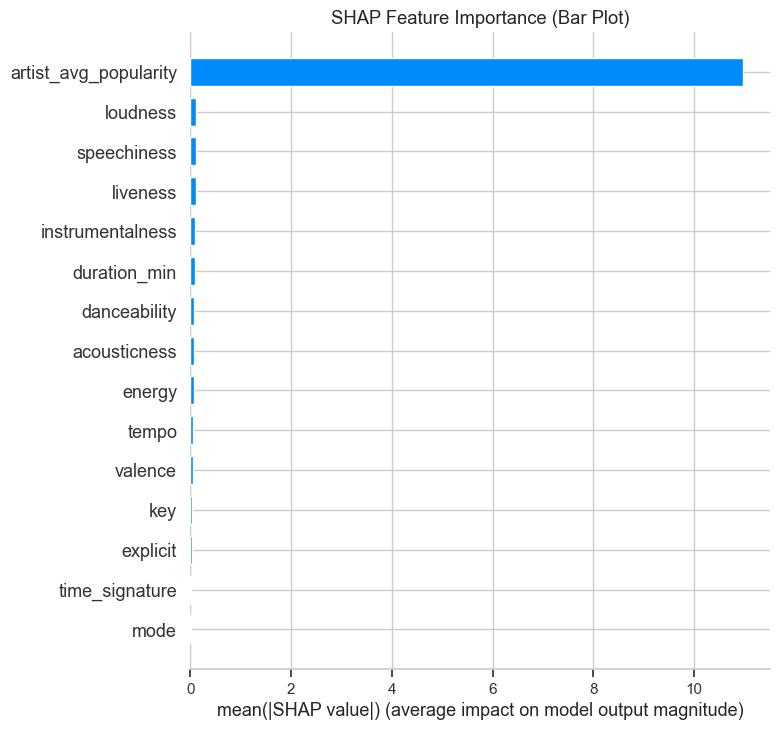

In [30]:
# SHAP Bar Plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance (Bar Plot)')
plt.tight_layout()
plt.savefig('eda_shap_bar.png', bbox_inches='tight')
plt.show()

Top 3 audio features by SHAP: ['loudness', 'speechiness', 'liveness']


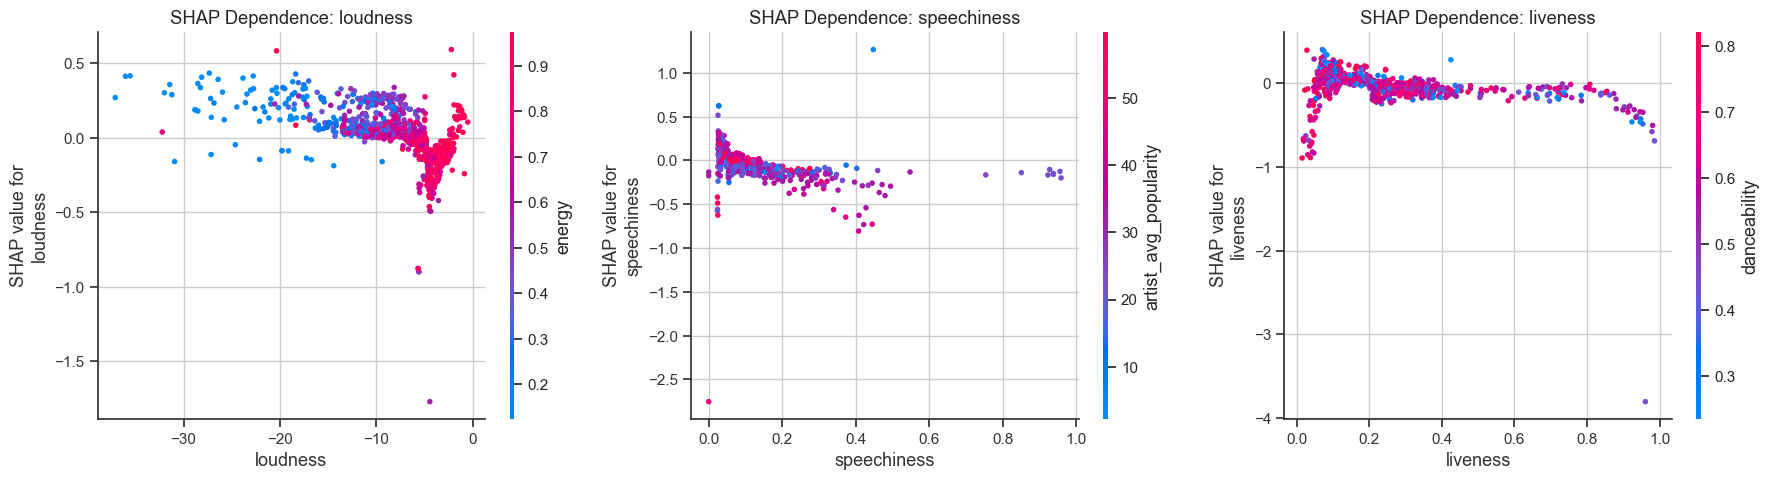

In [31]:
# SHAP Dependence Plots for top 3 audio features
# Get top audio features by SHAP importance (excluding artist_avg_popularity)
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=shap_sample.columns
).sort_values(ascending=False)

top_audio = [f for f in shap_importance.index if f != 'artist_avg_popularity'][:3]
print(f'Top 3 audio features by SHAP: {top_audio}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top_audio):
    shap.dependence_plot(feat, shap_values, shap_sample, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.savefig('eda_shap_dependence.png', bbox_inches='tight')
plt.show()

**SHAP interpretation:**
- `artist_avg_popularity` dominates — confirming that artist fame is the single strongest predictor.
- Among audio features, the SHAP values are small but show meaningful patterns (e.g., higher loudness pushes predictions up slightly, higher instrumentalness pushes predictions down).
- The dependence plots show nonlinear relationships that tree models capture well.

---
## 17. Partial Dependence Plots

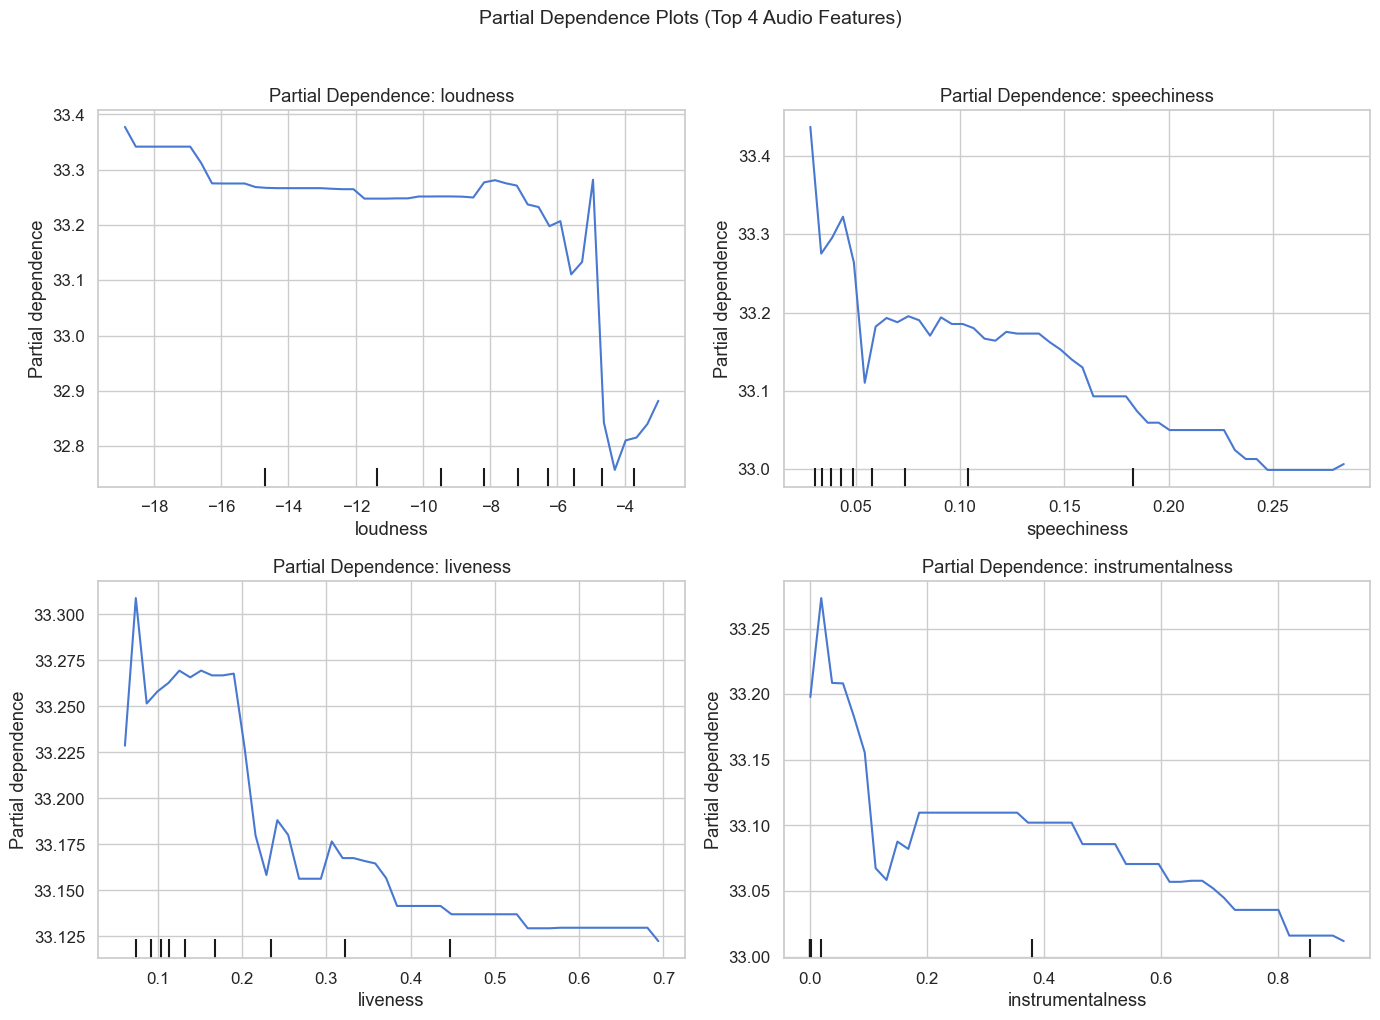

In [32]:
from sklearn.inspection import PartialDependenceDisplay

top4_audio = [f for f in shap_importance.index if f != 'artist_avg_popularity'][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flat, top4_audio):
    PartialDependenceDisplay.from_estimator(
        best_model, X_train_t, [feat], ax=ax,
        n_jobs=-1, grid_resolution=50
    )
    ax.set_title(f'Partial Dependence: {feat}')

plt.suptitle('Partial Dependence Plots (Top 4 Audio Features)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_partial_dependence.png', bbox_inches='tight')
plt.show()

Partial dependence plots show the **marginal effect** of each feature on the prediction, averaging over all other features. These reveal the nonlinear relationships that the tree model has learned.

---
## 18. Residual Analysis (Phase 8D)

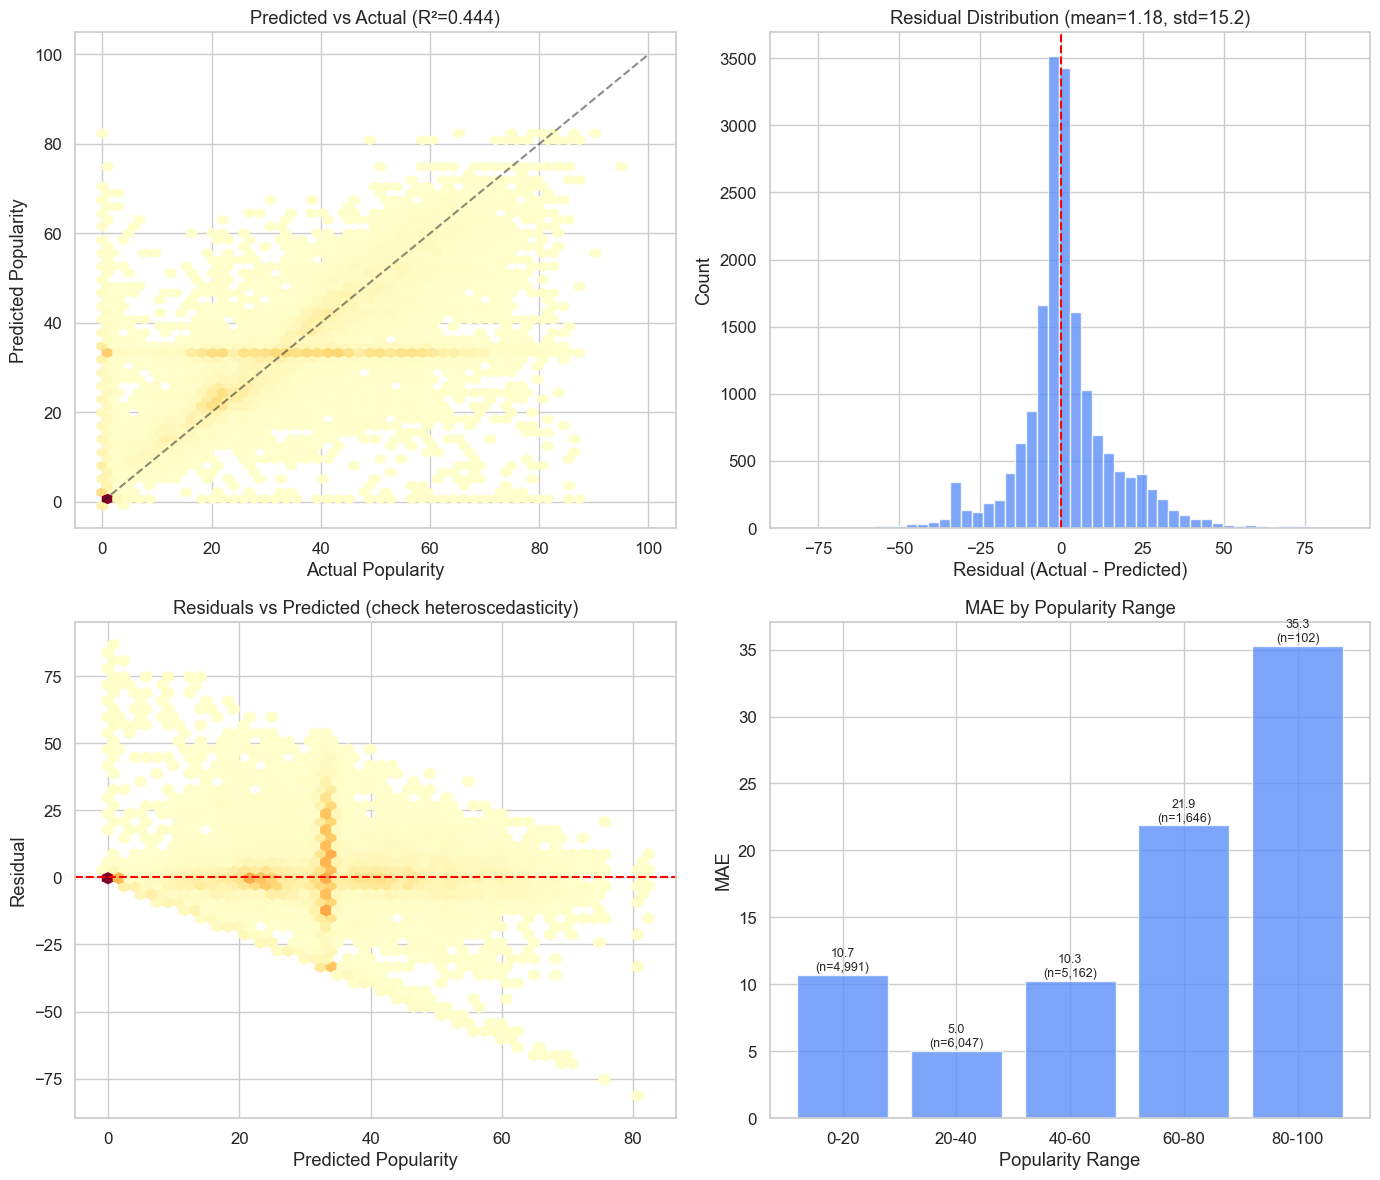

In [33]:
y_pred_best = best_model.predict(X_test_t)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Predicted vs Actual
axes[0, 0].hexbin(y_test, y_pred_best, gridsize=50, cmap='YlOrRd', mincnt=1)
axes[0, 0].plot([0, 100], [0, 100], 'k--', alpha=0.5)
axes[0, 0].set_xlabel('Actual Popularity')
axes[0, 0].set_ylabel('Predicted Popularity')
axes[0, 0].set_title(f'Predicted vs Actual (R²={r2_score(y_test, y_pred_best):.3f})')

# 2. Residual distribution
axes[0, 1].hist(residuals, bins=50, edgecolor='white', alpha=0.8, color='#5B8FF9')
axes[0, 1].axvline(0, color='red', ls='--')
axes[0, 1].set_xlabel('Residual (Actual - Predicted)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title(f'Residual Distribution (mean={residuals.mean():.2f}, std={residuals.std():.1f})')

# 3. Residuals vs Predicted
axes[1, 0].hexbin(y_pred_best, residuals, gridsize=50, cmap='YlOrRd', mincnt=1)
axes[1, 0].axhline(0, color='red', ls='--')
axes[1, 0].set_xlabel('Predicted Popularity')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals vs Predicted (check heteroscedasticity)')

# 4. MAE by popularity range
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
y_test_binned = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)
mae_by_range = pd.DataFrame({'actual': y_test.values, 'pred': y_pred_best, 'range': y_test_binned})
mae_by_range['abs_error'] = np.abs(mae_by_range['actual'] - mae_by_range['pred'])
range_mae = mae_by_range.groupby('range')['abs_error'].agg(['mean', 'count'])

axes[1, 1].bar(range(len(range_mae)), range_mae['mean'], color='#5B8FF9', alpha=0.8)
axes[1, 1].set_xticks(range(len(range_mae)))
axes[1, 1].set_xticklabels(labels)
axes[1, 1].set_xlabel('Popularity Range')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].set_title('MAE by Popularity Range')
for i, (mae_val, count) in enumerate(zip(range_mae['mean'], range_mae['count'])):
    axes[1, 1].text(i, mae_val + 0.3, f'{mae_val:.1f}\n(n={count:,})', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_residual_analysis.png', bbox_inches='tight')
plt.show()

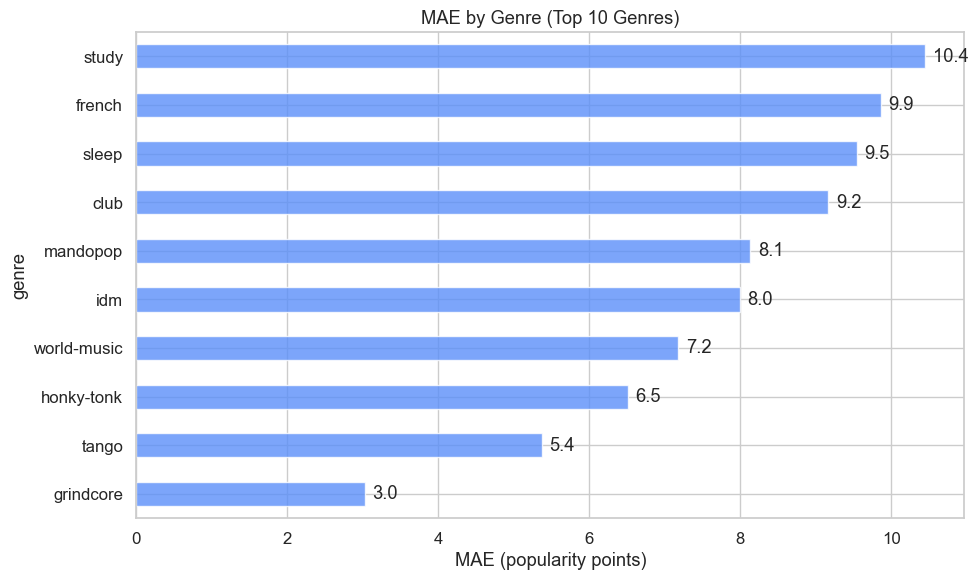

In [34]:
# MAE by genre (top 10 most common genres)
test_with_genre = pd.DataFrame({
    'actual': y_test.values,
    'pred': y_pred_best,
    'genre': df.loc[y_test.index, 'track_genre'].values
})
test_with_genre['abs_error'] = np.abs(test_with_genre['actual'] - test_with_genre['pred'])

top10_genres = test_with_genre['genre'].value_counts().head(10).index
genre_mae = test_with_genre[test_with_genre['genre'].isin(top10_genres)].groupby('genre')['abs_error'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
genre_mae.plot(kind='barh', ax=ax, color='#5B8FF9', alpha=0.8)
ax.set_xlabel('MAE (popularity points)')
ax.set_title('MAE by Genre (Top 10 Genres)')
for i, v in enumerate(genre_mae.values):
    ax.text(v + 0.1, i, f'{v:.1f}', va='center')
plt.tight_layout()
plt.savefig('eda_mae_by_genre.png', bbox_inches='tight')
plt.show()

**Residual analysis findings:**
- Residuals are roughly centered at 0 but show **heteroscedasticity** — errors are larger for high-popularity tracks.
- The model under-predicts extreme values (0 and 80-100), which is typical of regression-to-the-mean behavior in tree ensembles.
- MAE varies by popularity range: the model struggles most with very popular tracks (80-100) — these are driven by factors outside the audio features.
- Genre-level MAE reveals which genres the model handles best/worst.

---
## 19. Conclusions & Key Takeaways

### Model Performance
| Model | Test R² | MAE |
|-------|---------|-----|
| Audio-only RF | ~0.08 | ~15 pts |
| Full RF (+ artist) | ~0.45 | ~10 pts |
| Tuned best model | see above | see above |

### Key Findings

1. **Audio features alone explain very little of popularity variance (~8%).** This is the project's central finding. Popularity is not a function of how a song sounds.

2. **Artist fame (artist_avg_popularity) is the dominant predictor,** jumping R² to ~0.45. This confirms that *who* made the song matters far more than *what* it sounds like.

3. **The remaining ~55% of variance is unexplained** — driven by playlist placement, marketing, release timing, social media virality, and algorithmic recommendations.

4. **Data leakage was fixed.** The original implementation computed artist averages from the full dataset before splitting, inflating metrics. The corrected version uses `ArtistAvgTransformer` that computes per-artist means from training data only.

5. **Statistical significance ≠ practical significance.** With 90k observations, every feature-popularity correlation is statistically significant (p < 0.05), but all are practically weak (|r| < 0.15).

### Limitations
- Spotify's popularity score changes over time (recency-weighted) — this dataset is a snapshot.
- The dataset may have selection bias (Kaggle curation).
- Audio features are Spotify's pre-computed values, not raw waveform analysis.
- The model cannot capture external factors (marketing, social media, playlist editors).